In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from analysis_utils import *

First define the two experiments to be compared:

In [34]:
results_1 = "./analysis_results/2022_barn_2secs_myca_quantile_1_16"
results_2 = "./analysis_results/2022_lake_2secs_myca_quantile_1_28"

In [35]:
chirp_attributes_1 = pd.read_csv(f"{results_1}/test_set_chirp_attributes.csv")
idiom_boundaries_1 = pd.read_csv(f"{results_1}/idiom_boundaries.csv", header=None)
confidence_measures_1 = pd.read_csv(f"{results_1}/chirp_prediction_confidence_measures.csv")
scaler_1 = joblib.load(open(f'{results_1}/split_scaler.pkl', 'rb'))

chirp_attributes_2 = pd.read_csv(f"{results_2}/test_set_chirp_attributes.csv")
idiom_boundaries_2 = pd.read_csv(f"{results_2}/idiom_boundaries.csv", header=None)
confidence_measures_2 = pd.read_csv(f"{results_2}/chirp_prediction_confidence_measures.csv")
scaler_2 = joblib.load(open(f'{results_1}/split_scaler.pkl', 'rb'))

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [36]:
combined_chirp_attributes = pd.concat([chirp_attributes_1, chirp_attributes_2], ignore_index=True)
combined_chirp_attributes.rename({"Unnamed: 0": "OriginalIndex"}, axis=1, inplace=True)
idiom_boundaries_attributes = pd.concat([idiom_boundaries_1, idiom_boundaries_2], ignore_index=True)
idiom_boundaries_attributes.rename({"Unnamed: 0": "OriginalIndex"}, axis=1, inplace=True)
confidence_measures_attributes = pd.concat([confidence_measures_1, confidence_measures_2], ignore_index=True)
confidence_measures_attributes.rename({"Unnamed: 0": "OriginalIndex"}, axis=1, inplace=True)
combined_chirp_attributes

,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,...,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx
0,0,1514.999990,86.0,73.442747,27.074597,54.179102,54.729164,52.135644,64.509295,73.442747,...,8769.741215,15616.055230,12429.542955,14.097721,9.354195,129.228862,106.436745,4.470350,16693.0,4.0
1,1,1848.999988,82.0,85.892290,40.796518,51.132176,68.501612,65.281315,23.025752,85.892290,...,14213.696222,20336.769621,7052.027650,23.177943,19.795116,166.116571,154.967097,13.441341,16694.0,19.0
2,2,1680.000025,83.0,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,82.795382,...,4357.833382,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0
3,3,1596.999944,90.0,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,83.515950,...,18380.062892,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0
4,4,1506.999984,79.0,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,87.488464,...,19015.930484,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11448,553,841.000000,83.0,81.035584,37.821823,51.582073,83.468548,65.033890,24.365660,81.035584,...,4887.441377,11099.693264,15919.280542,15.358730,13.988858,130.665691,127.053089,29.723413,1090.0,10.0
11449,554,760.000002,92.0,58.853195,12.959059,58.775493,13.723397,52.235091,51.843939,58.853195,...,17695.370816,12035.236563,13587.113381,7.009519,6.448170,98.820913,96.478195,2.011489,1090.0,9.0
11450,555,667.999984,82.0,65.957392,19.876931,54.738491,60.806593,57.253009,39.290414,65.957392,...,13915.889054,24750.163596,20832.871446,6.718294,5.959550,97.351306,93.523707,8.847997,1090.0,8.0
11451,556,584.000001,88.0,72.620507,23.149131,54.206671,64.633530,59.687491,26.399611,72.620507,...,13638.972049,21300.105497,13989.804504,12.287033,5.459047,97.874026,78.810162,2.155864,1090.0,7.0


In [37]:
for dataframe, df_1 in [(combined_chirp_attributes, chirp_attributes_1), 
                        (idiom_boundaries_attributes, idiom_boundaries_1), 
                        (confidence_measures_attributes, confidence_measures_1)]:
    dataframe["original_df"] = dataframe.apply(lambda x: 1 if x.name < len(df_1) else 2, axis=1)
combined_chirp_attributes

,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,original_df
0,0,1514.999990,86.0,73.442747,27.074597,54.179102,54.729164,52.135644,64.509295,73.442747,...,15616.055230,12429.542955,14.097721,9.354195,129.228862,106.436745,4.470350,16693.0,4.0,1
1,1,1848.999988,82.0,85.892290,40.796518,51.132176,68.501612,65.281315,23.025752,85.892290,...,20336.769621,7052.027650,23.177943,19.795116,166.116571,154.967097,13.441341,16694.0,19.0,1
2,2,1680.000025,83.0,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,82.795382,...,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0,1
3,3,1596.999944,90.0,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,83.515950,...,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0,1
4,4,1506.999984,79.0,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,87.488464,...,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11448,553,841.000000,83.0,81.035584,37.821823,51.582073,83.468548,65.033890,24.365660,81.035584,...,11099.693264,15919.280542,15.358730,13.988858,130.665691,127.053089,29.723413,1090.0,10.0,2
11449,554,760.000002,92.0,58.853195,12.959059,58.775493,13.723397,52.235091,51.843939,58.853195,...,12035.236563,13587.113381,7.009519,6.448170,98.820913,96.478195,2.011489,1090.0,9.0,2
11450,555,667.999984,82.0,65.957392,19.876931,54.738491,60.806593,57.253009,39.290414,65.957392,...,24750.163596,20832.871446,6.718294,5.959550,97.351306,93.523707,8.847997,1090.0,8.0,2
11451,556,584.000001,88.0,72.620507,23.149131,54.206671,64.633530,59.687491,26.399611,72.620507,...,21300.105497,13989.804504,12.287033,5.459047,97.874026,78.810162,2.155864,1090.0,7.0,2


Visualize how the two experiments are distributed in a 2-D projection:

In [38]:
import umap
combined_chirp_attributes_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(combined_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy())

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


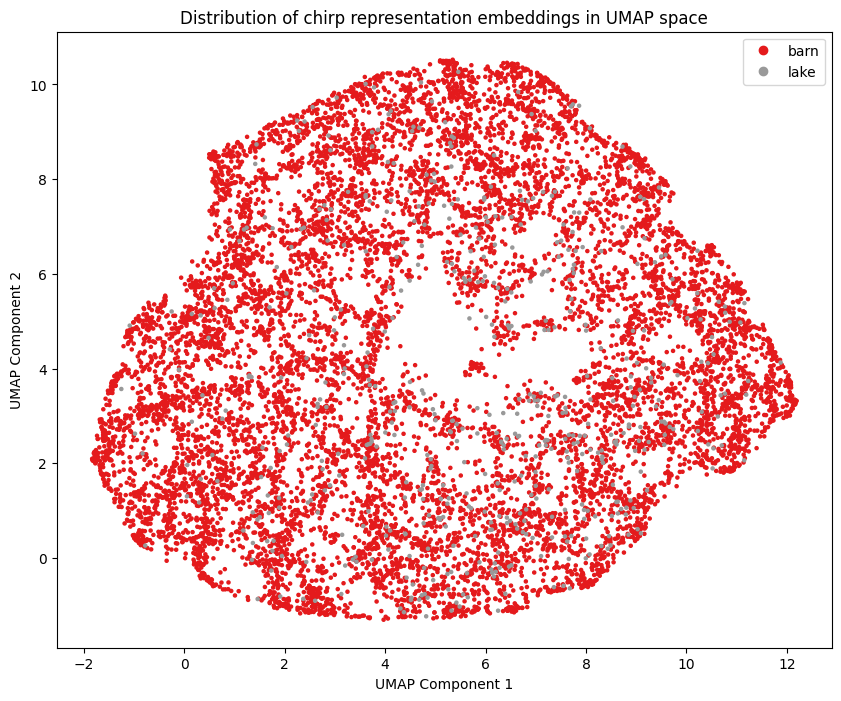

In [39]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(combined_chirp_attributes_embedded[:, 0], 
                      combined_chirp_attributes_embedded[:, 1], 
                      c=combined_chirp_attributes["original_df"], 
                      cmap="Set1", 
                      s=5,
                      )
plt.title(f"Distribution of chirp representation embeddings in UMAP space")
handles, labels = scatter.legend_elements()
plt.legend(handles, ["barn", "lake"])
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

In [40]:
idiom_boundaries_attributes

,0,1,original_df
0,2.0,11.0,1
1,49.0,54.0,1
2,62.0,70.0,1
3,95.0,99.0,1
4,111.0,115.0,1
...,...,...,...
637,382.0,386.0,2
638,437.0,443.0,2
639,462.0,466.0,2
640,467.0,472.0,2


Visualize the distribution of only idiom chirps (chirps within a "whole" idiom):

In [41]:
# get the idiom chirp attributes
idiom_chirp_idxs = []
for idx, row in idiom_boundaries_attributes.iterrows():
    for i in range(int(row[0]), int(row[1]) + 1):
        idiom_chirp_idxs.append((idx, i, row["original_df"]))

idiom_chirp_attributes = pd.DataFrame()
for idiom_idx, chirp_idx, original_df in idiom_chirp_idxs:
    attributes = combined_chirp_attributes.loc[(combined_chirp_attributes["original_df"] == original_df) & 
                                                (combined_chirp_attributes["OriginalIndex"] == chirp_idx)]
    if idiom_chirp_attributes.empty:
        idiom_chirp_attributes = attributes
    else:
        idiom_chirp_attributes = pd.concat([idiom_chirp_attributes, attributes])
idiom_chirp_attributes.reset_index(inplace=True)
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,original_df
0,2,2,1680.000025,83.000000,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,...,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0,1
1,3,3,1596.999944,90.000000,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,...,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0,1
2,4,4,1506.999984,79.000000,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,...,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0,1
3,5,5,1338.000015,81.000000,88.675825,45.164369,53.692662,54.726804,61.536750,28.691722,...,15579.253756,15225.152192,26.305368,20.552334,182.140376,159.267579,5.644597,16694.0,15.0,1
4,6,6,1257.999994,90.000000,79.066596,32.974939,49.437098,80.856611,63.246841,20.791700,...,9075.354376,19684.511002,18.863124,17.109394,152.684928,149.200427,27.468304,16694.0,14.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,11439,544,1238.999989,55.000000,103.007111,56.885528,58.730615,57.731113,74.702106,26.241414,...,11316.982123,11650.711411,28.783874,31.082635,223.935242,252.810892,8.119629,1089.0,9.0,2
4076,11440,545,1184.000002,53.000000,98.284760,44.270036,58.485972,82.147469,74.192283,37.339758,...,16615.629503,16091.092995,28.755010,31.217452,234.964736,271.874665,-6.012109,1089.0,8.0,2
4077,11441,546,1132.000007,166.000004,89.436597,43.714378,57.158957,65.008663,57.053220,66.057189,...,18380.929975,13654.596595,58.218397,49.417561,838.909005,687.387395,6.342850,1089.0,7.0,2
4078,11442,547,877.000000,162.000000,71.931755,26.541425,58.034384,49.148269,53.487984,69.734334,...,13868.277460,9406.794472,16.842018,10.441945,182.089148,129.617425,6.902197,1089.0,6.0,2


In [42]:
NO_AMP = 2 # set to 0 to keep all amp features, 1 to remove [Amp1stQrtl, Amp2ndQrtl, Amp3rdQrtl, Amp4thQrtl], 2 to remove all amp features

idiom_chirp_data = idiom_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy()

# remove columns that contain "Amp" in their name if NO_AMP is set
if NO_AMP == 1:
    amp_indices = [i - 3 for i, col in enumerate(idiom_chirp_attributes.columns) if col in ["Amp1stQrtl", "Amp2ndQrtl", "Amp3rdQrtl", "Amp4thQrtl"]]
    idiom_chirp_data = np.delete(idiom_chirp_data, amp_indices, axis=1)
elif NO_AMP == 2:
    amp_indices = [i - 3 for i, col in enumerate(idiom_chirp_attributes.columns) if "Amp" in col]
    idiom_chirp_data = np.delete(idiom_chirp_data, amp_indices, axis=1)

In [43]:
idiom_chirp_data

array([[ 83.        ,  82.79538209,  39.38426898, ...,  21.59366399,
        134.55166679, 159.31685522],
       [ 90.        ,  83.51594998,  40.84173298, ...,  17.64491616,
        130.23759435, 135.98649126],
       [ 79.        ,  87.48846404,  46.04536814, ...,  23.78813603,
        205.13183568, 178.56542901],
       ...,
       [166.00000377,  89.43659715,  43.71437815, ...,  49.41756082,
        838.90900498, 687.38739465],
       [162.        ,  71.931755  ,  26.54142513, ...,  10.44194493,
        182.08914773, 129.61742533],
       [ 84.        ,  67.51561753,  23.38730885, ...,   3.92382693,
        103.57659262,  78.48294328]])

In [44]:
idiom_chirp_attributes_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(idiom_chirp_data)

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


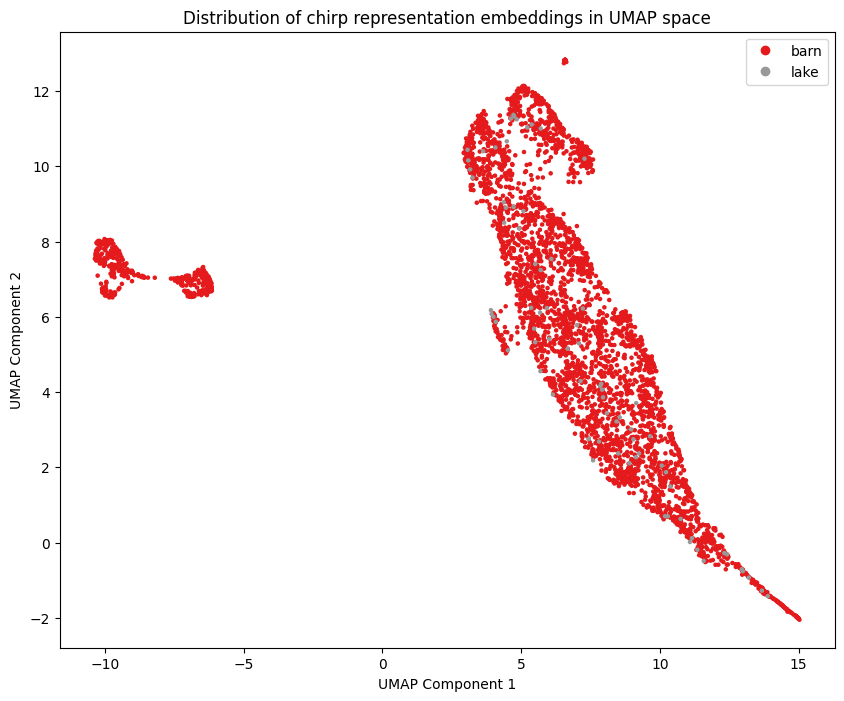

In [45]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(idiom_chirp_attributes_embedded[:, 0], 
                      idiom_chirp_attributes_embedded[:, 1], 
                      c=idiom_chirp_attributes["original_df"], 
                      cmap="Set1", 
                      s=5,
                      )
plt.title(f"Distribution of chirp representation embeddings in UMAP space")
handles, labels = scatter.legend_elements()
plt.legend(handles, ["barn", "lake"])
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

Run clustering on the set of idiom chirps combined from both idioms:

In [46]:
MIN_K = 1
MAX_K = 50

n_clusters = find_ideal_cluster_k(idiom_chirp_attributes_embedded, MIN_K, MAX_K, plot=False)
n_clusters

100%|██████████| 49/49 [00:13<00:00,  3.72it/s]


{'gap_statistic': 49, 'diff_statistic': 1, 'elbow_method': 10}

In [47]:
clustering = "Agglomerative"
use_umap = True
NUM_CLUSTERS = n_clusters["elbow_method"]

cluster_data_input = idiom_chirp_attributes_embedded if use_umap else idiom_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy()
chirp_labels = cluster_chirps(cluster_data_input, clustering, use_umap, NUM_CLUSTERS)

chirp_labels

array([2, 2, 0, ..., 5, 3, 1])

In [48]:
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,original_df
0,2,2,1680.000025,83.000000,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,...,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0,1
1,3,3,1596.999944,90.000000,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,...,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0,1
2,4,4,1506.999984,79.000000,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,...,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0,1
3,5,5,1338.000015,81.000000,88.675825,45.164369,53.692662,54.726804,61.536750,28.691722,...,15579.253756,15225.152192,26.305368,20.552334,182.140376,159.267579,5.644597,16694.0,15.0,1
4,6,6,1257.999994,90.000000,79.066596,32.974939,49.437098,80.856611,63.246841,20.791700,...,9075.354376,19684.511002,18.863124,17.109394,152.684928,149.200427,27.468304,16694.0,14.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,11439,544,1238.999989,55.000000,103.007111,56.885528,58.730615,57.731113,74.702106,26.241414,...,11316.982123,11650.711411,28.783874,31.082635,223.935242,252.810892,8.119629,1089.0,9.0,2
4076,11440,545,1184.000002,53.000000,98.284760,44.270036,58.485972,82.147469,74.192283,37.339758,...,16615.629503,16091.092995,28.755010,31.217452,234.964736,271.874665,-6.012109,1089.0,8.0,2
4077,11441,546,1132.000007,166.000004,89.436597,43.714378,57.158957,65.008663,57.053220,66.057189,...,18380.929975,13654.596595,58.218397,49.417561,838.909005,687.387395,6.342850,1089.0,7.0,2
4078,11442,547,877.000000,162.000000,71.931755,26.541425,58.034384,49.148269,53.487984,69.734334,...,13868.277460,9406.794472,16.842018,10.441945,182.089148,129.617425,6.902197,1089.0,6.0,2


In [49]:
import matplotlib 
from matplotlib.colors import ListedColormap

cmap1_colors = matplotlib.colormaps["tab10"](np.linspace(0, 1, 256))
cmap2_colors = cmap1_colors * 0.5
cmap2_colors[:, 3] = 1
cmap2_colors
cmap2 = ListedColormap(cmap2_colors, name="Set1dark")

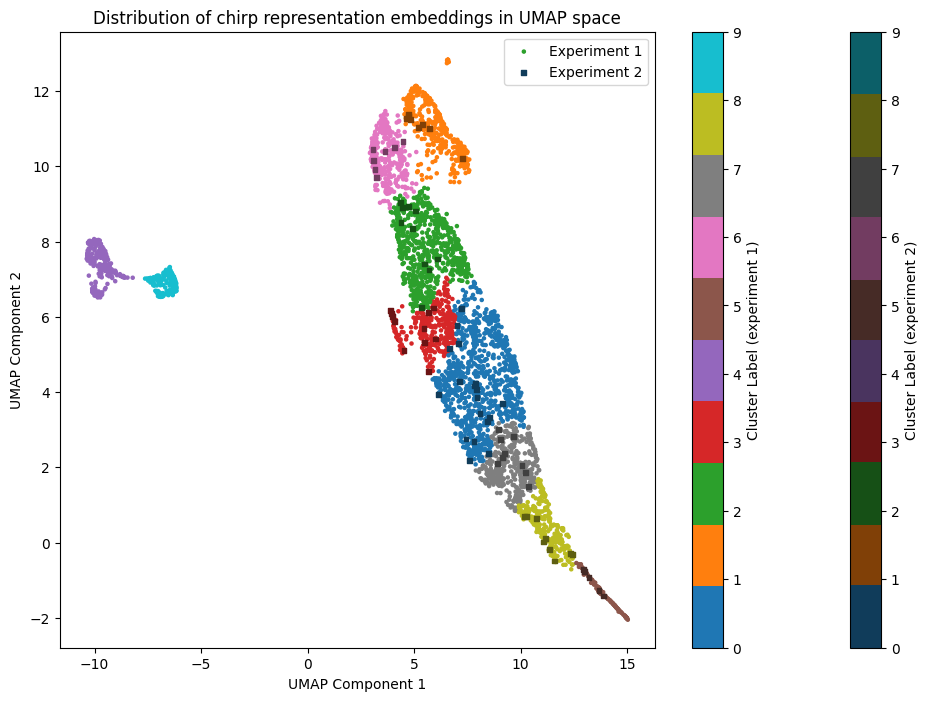

In [50]:
# plot the idiom chirps with their clusters, with the two experiments designated with different shapes
second_exp_first_row = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 2].iloc[0].name

plt.figure(figsize=(12, 8))
scatter1 = plt.scatter(idiom_chirp_attributes_embedded[:second_exp_first_row, 0], 
                      idiom_chirp_attributes_embedded[:second_exp_first_row, 1], 
                      c=chirp_labels[:second_exp_first_row], 
                      cmap="tab10", 
                      s=5, 
                      vmin=min(chirp_labels), 
                      vmax=NUM_CLUSTERS - 1
                      )
scatter2 = plt.scatter(idiom_chirp_attributes_embedded[second_exp_first_row:, 0], 
                      idiom_chirp_attributes_embedded[second_exp_first_row:, 1], 
                      c=chirp_labels[second_exp_first_row:], 
                      cmap=cmap2, 
                      s=12, 
                      marker="s",
                      vmin=min(chirp_labels), 
                      vmax=NUM_CLUSTERS - 1
                      )
plt.title(f"Distribution of chirp representation embeddings in UMAP space")
# handles, labels = scatter1.legend_elements()
# plt.legend(handles, ["barn", "lake"])
plt.colorbar(scatter2, label="Cluster Label (experiment 2)")
plt.colorbar(scatter1, label="Cluster Label (experiment 1)")
plt.legend(["Experiment 1", "Experiment 2"])

plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

In [51]:
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,original_df
0,2,2,1680.000025,83.000000,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,...,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0,1
1,3,3,1596.999944,90.000000,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,...,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0,1
2,4,4,1506.999984,79.000000,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,...,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0,1
3,5,5,1338.000015,81.000000,88.675825,45.164369,53.692662,54.726804,61.536750,28.691722,...,15579.253756,15225.152192,26.305368,20.552334,182.140376,159.267579,5.644597,16694.0,15.0,1
4,6,6,1257.999994,90.000000,79.066596,32.974939,49.437098,80.856611,63.246841,20.791700,...,9075.354376,19684.511002,18.863124,17.109394,152.684928,149.200427,27.468304,16694.0,14.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,11439,544,1238.999989,55.000000,103.007111,56.885528,58.730615,57.731113,74.702106,26.241414,...,11316.982123,11650.711411,28.783874,31.082635,223.935242,252.810892,8.119629,1089.0,9.0,2
4076,11440,545,1184.000002,53.000000,98.284760,44.270036,58.485972,82.147469,74.192283,37.339758,...,16615.629503,16091.092995,28.755010,31.217452,234.964736,271.874665,-6.012109,1089.0,8.0,2
4077,11441,546,1132.000007,166.000004,89.436597,43.714378,57.158957,65.008663,57.053220,66.057189,...,18380.929975,13654.596595,58.218397,49.417561,838.909005,687.387395,6.342850,1089.0,7.0,2
4078,11442,547,877.000000,162.000000,71.931755,26.541425,58.034384,49.148269,53.487984,69.734334,...,13868.277460,9406.794472,16.842018,10.441945,182.089148,129.617425,6.902197,1089.0,6.0,2


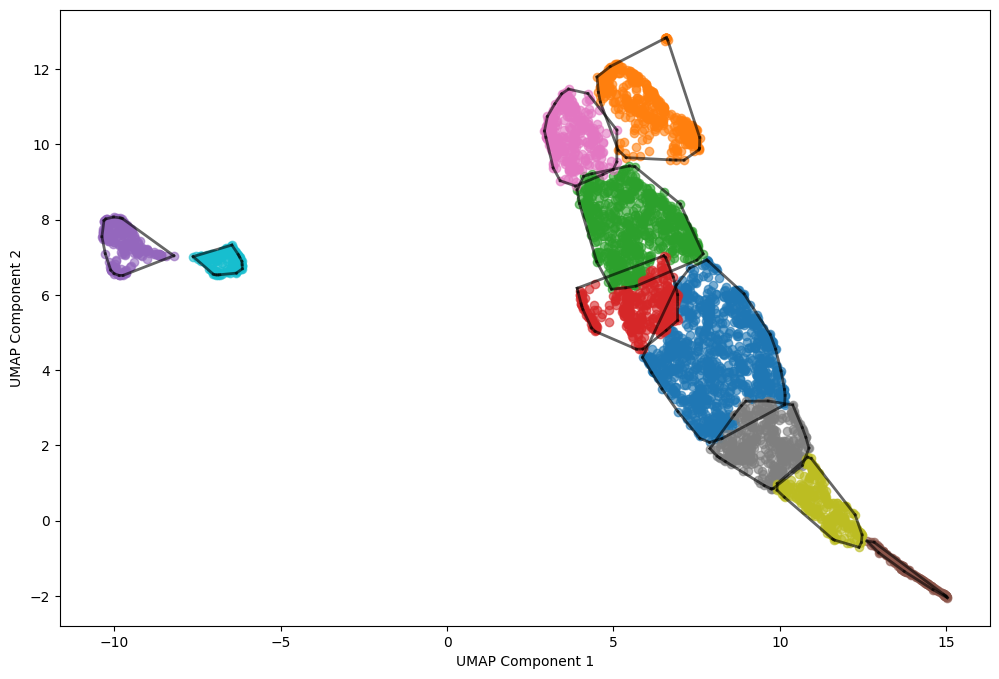

In [70]:
from scipy.spatial import ConvexHull, convex_hull_plot_2d
plt.figure(figsize=(12, 8))
idiom_chirp_attributes['cluster_idx'] = chirp_labels

first_exp_attributes_embedded = idiom_chirp_attributes_embedded[:second_exp_first_row]
second_exp_attributes_embedded = idiom_chirp_attributes_embedded[second_exp_first_row:]
for i in range(NUM_CLUSTERS):
    if len(cluster_points) > 2:
        hull = ConvexHull(cluster_points)
        # Plot the hull as a closed line
        for simplex in hull.simplices:
            plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 'k-', lw=2, alpha=0.6) # 'k-' for a solid black line
    cluster_points = idiom_chirp_attributes_embedded[idiom_chirp_attributes['cluster_idx'] == i]
    first_exp_cluster_points = first_exp_attributes_embedded[idiom_chirp_attributes['cluster_idx'][:second_exp_first_row] == i]
    second_exp_cluster_points = second_exp_attributes_embedded[idiom_chirp_attributes['cluster_idx'][second_exp_first_row:] == i]
    scatter = plt.scatter(first_exp_cluster_points[:, 0], first_exp_cluster_points[:, 1], label=f'Cluster {i}', alpha=0.6)

plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");

Evaluate various metrics about the clustering of the two sets of idiom chirps:

In [53]:

idiom_label_sequences = idiom_chirp_attributes.groupby(["file_id", "original_df"]).agg(list)["cluster_idx"].reset_index()
idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]

,file_id,original_df,cluster_idx
10,16694.0,1,"[2, 2, 0, 3, 1, 0, 0, 3, 0, 1]"
11,16698.0,1,"[2, 6, 3, 1, 2, 1]"
12,16699.0,1,"[1, 6, 0, 0, 0, 0, 8, 7, 5]"
13,16702.0,1,"[3, 1, 7, 7, 0]"
14,16703.0,1,"[6, 9, 1, 1, 1, 6, 3, 0]"
...,...,...,...
378,17496.0,1,"[5, 5, 2, 2, 2, 0, 2, 1, 7, 7, 7, 0]"
379,17499.0,1,"[0, 7, 3, 3, 0, 3, 0]"
380,17514.0,1,"[1, 4, 0, 1, 2, 7, 6, 8, 2, 3, 7, 2]"
381,17516.0,1,"[0, 4, 1, 0, 4, 0, 2]"


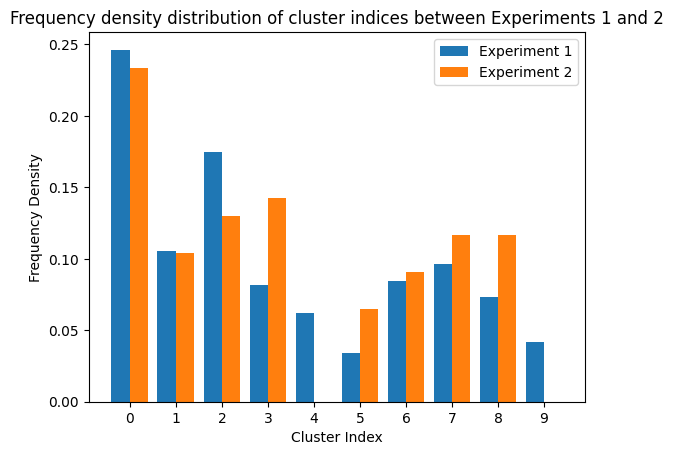

In [54]:
# plot a histogram of cluster indices across the two experiments
first_exp_clusters = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 1]['cluster_idx'].values
second_exp_clusters = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 2]['cluster_idx'].values
plt.hist([first_exp_clusters, second_exp_clusters], 
         bins=(np.arange(min(chirp_labels), max(chirp_labels) + 2) - 0.5), 
         density=True,
        #  stacked=True,
         )
plt.xticks(range(min(chirp_labels), max(chirp_labels) + 1))
plt.title("Frequency density distribution of cluster indices between Experiments 1 and 2")
plt.xlabel("Cluster Index")
plt.ylabel("Frequency Density")
plt.legend(["Experiment 1", "Experiment 2"]);

In [55]:
# find the most common cluster across both experiments
LENGTH = 1
K_MOST_COMMON = 10
SUBSEQ_TYPE = "all"
subseq_all = most_common_subsequences(idiom_label_sequences['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE, 
                         k=K_MOST_COMMON)
subseq_exp1 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_exp2 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 2]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_all = pd.DataFrame(subseq_all, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} (all)', 'Count'])
subseq_exp1 = pd.DataFrame(subseq_exp1, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} (exp 1)', 'Count'])
subseq_exp2 = pd.DataFrame(subseq_exp2, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} (exp 2)', 'Count'])
print(pd.concat([subseq_all, subseq_exp1, subseq_exp2], axis=1))

  Subseq (all)  Count Subseq (exp 1)  Count Subseq (exp 2)  Count
0         (0,)   1004           (0,)    986           (0,)   18.0
1         (2,)    710           (2,)    700           (3,)   11.0
2         (1,)    429           (1,)    421           (2,)   10.0
3         (7,)    394           (7,)    385           (7,)    9.0
4         (6,)    345           (6,)    338           (8,)    9.0
5         (3,)    338           (3,)    327           (1,)    8.0
6         (8,)    302           (8,)    293           (6,)    7.0
7         (4,)    249           (4,)    249           (5,)    5.0
8         (9,)    167           (9,)    167            NaN    NaN
9         (5,)    142           (5,)    137            NaN    NaN


In [56]:
# find most common transitions
LENGTH = 2
subseq_all = most_common_subsequences(idiom_label_sequences['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE, 
                         k=K_MOST_COMMON)
subseq_exp1 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_exp2 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 2]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_all = pd.DataFrame(subseq_all, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} (all)', 'Count'])
subseq_exp1 = pd.DataFrame(subseq_exp1, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} (exp 1)', 'Count'])
subseq_exp2 = pd.DataFrame(subseq_exp2, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} (exp 2)', 'Count'])
print(pd.concat([subseq_all, subseq_exp1, subseq_exp2], axis=1))

  Subseq (all)  Count Subseq (exp 1)  Count Subseq (exp 2)  Count
0       (0, 0)    264         (0, 0)    260         (8, 0)      5
1       (2, 2)    153         (2, 2)    152         (0, 8)      4
2       (2, 0)    138         (2, 0)    138         (0, 0)      4
3       (0, 2)    136         (0, 2)    136         (2, 6)      3
4       (7, 0)     97         (7, 0)     95         (0, 3)      3
5       (0, 7)     89         (0, 7)     89         (3, 0)      3
6       (3, 0)     87         (3, 0)     84         (0, 1)      2
7       (0, 3)     78         (0, 3)     75         (7, 0)      2
8       (0, 1)     76         (1, 0)     75         (8, 2)      2
9       (1, 0)     75         (0, 1)     74         (2, 3)      2


Stepping away from comparison for a second, this section allows us to describe the characteristics of a given cluster

In [57]:
ignore_columns = ["index", "OriginalIndex", "file_id", "chirp_idx", "original_df", "cluster_idx"]
cluster_profile = describe_cluster(idiom_chirp_attributes, 7, normalize=True, ignore_columns=ignore_columns)
cluster_profile

TimeInFile        -0.147583
PrecedingIntrvl    0.093185
HiFreq             0.834074
Bndwdth            0.799458
FreqMaxPwr         0.452217
PrcntMaxAmpDur     0.070155
FreqKnee           0.508449
PrcntKneeDur       0.235602
StartF             0.834887
UpprKnFreq         0.619047
HiFtoUpprKnAmp     0.967833
HiFtoKnAmp         0.943060
HiFtoFcAmp         0.849849
UpprKnToKnAmp     -1.527786
KnToFcAmp          0.708208
LdgToFcAmp         0.457731
FreqCtr            0.595028
FFwd32dB           0.329365
FFwd20dB           0.615517
FFwd15dB           0.630754
FBak5dB            0.458928
FFwd5dB            0.539160
Bndw32dB           0.248161
Amp1stQrtl        -0.331537
Amp2ndQrtl        -0.192060
Amp3rdQrtl        -0.040811
Amp4thQrtl        -0.196559
1st10kHzSlp        0.906192
1st5to15kHzSlp     0.930049
1st10kHzExp        0.982346
1st5to15kHzExp     0.983847
AmpK@start         0.065350
dtype: float64